<div style="background-color:#ED1C24; color:white; padding:20px 30px; border-radius:10px;">
<h1 style="color:white; margin:0;">Session 7.2: Statistical Inference & Hypothesis Testing</h1>
<p style="color:white; margin:5px 0 0 0;">Practical Lab — CLT, Confidence Intervals, P-values & A/B Testing</p>
</div>

## Learning Objectives

1. Demonstrate the CLT through simulation
2. Compute standard error and understand its relationship to sample size
3. Construct and interpret 95% confidence intervals
4. Set up hypothesis tests with H₀ and H₁
5. Compute p-values and make decisions
6. Understand Type I and Type II errors
7. Analyze an A/B test with `scipy.stats.ttest_ind()`

## Setup

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)
print("Setup complete!")

Setup complete!


<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 1: Central Limit Theorem</h2>
</div>

The CLT says: sample means → Normal, regardless of the population shape (for n ≥ 30).

In [2]:
heights = np.random.randint(145,190,100000)
print(heights.mean())
print(heights.std())

167.05123
12.97009196139719


167.033116
0.3977421105993184


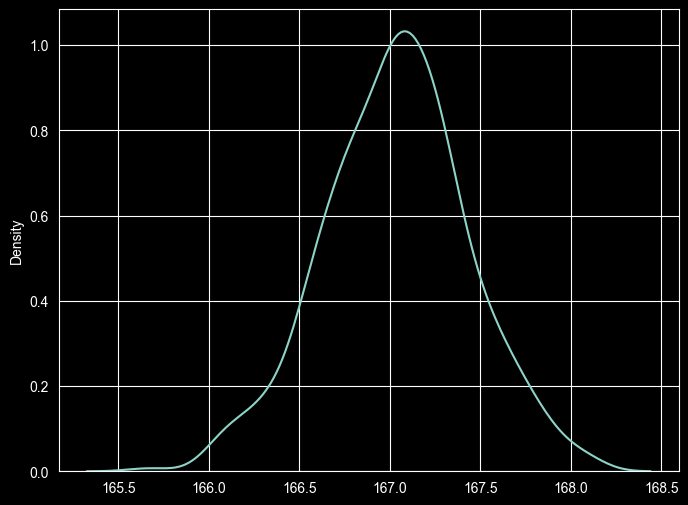

In [5]:
n=1000
sample_means= []
for i in range(500):
  sample = np.random.choice(heights,size=n)
  sample_means.append(sample.mean())
print(np.array(sample_means).mean())
print(np.array(sample_means).std())
plt.figure(figsize=(8, 6))
# sns.histplot(data=sample_means,kde=True)
sns.kdeplot(data=sample_means)
plt.show()

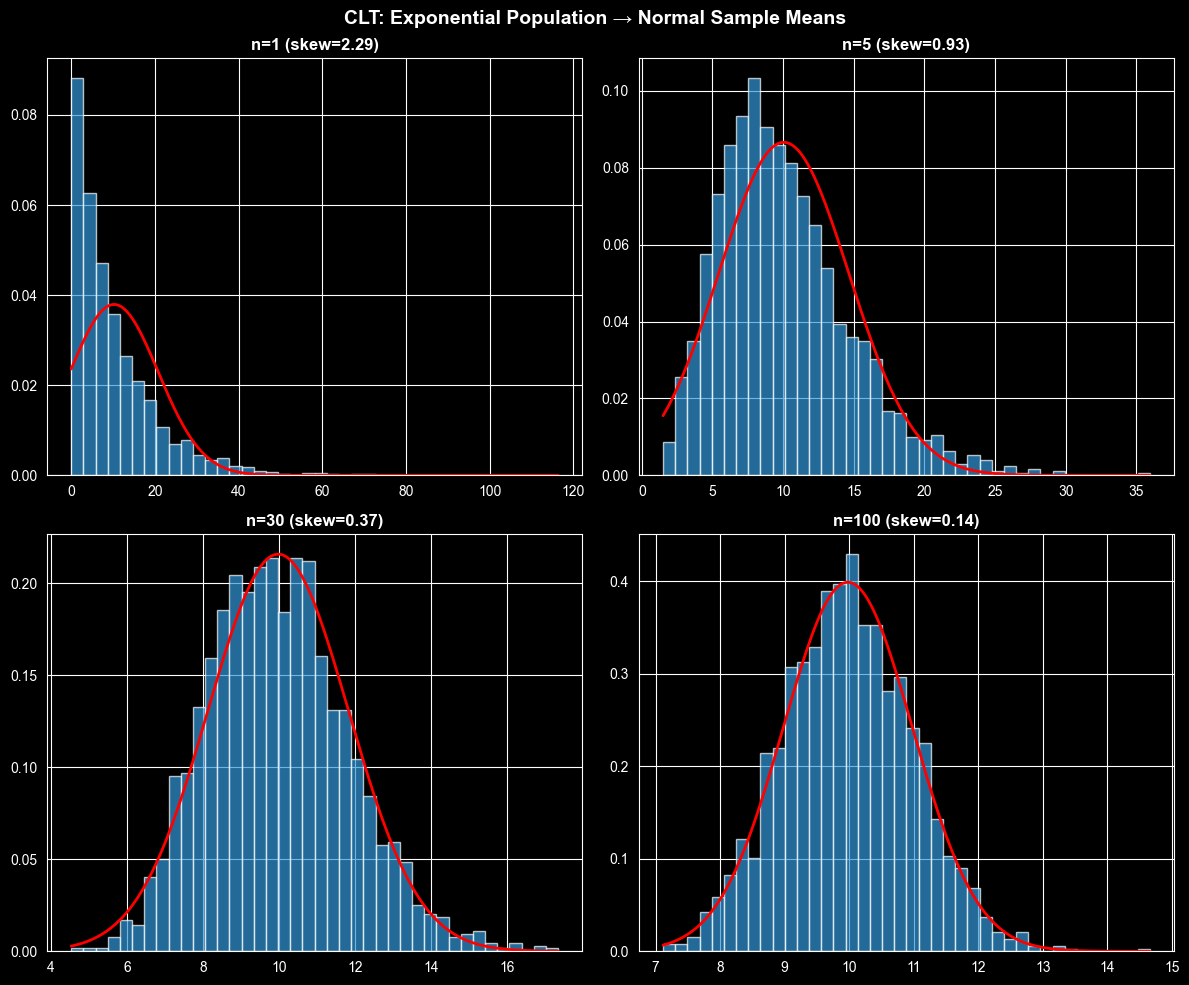

Population: mean=10.0, std=9.9
Predicted SE (n=30): σ/√n = 1.82


In [7]:
# Population: Exponential (very right-skewed!)
population = np.random.exponential(scale=10, size=100000)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, n in zip(axes.flat, [1, 5, 30, 100]):
    means = [np.mean(np.random.choice(population, size=n)) for _ in range(2000)]
    ax.hist(means, bins=40, density=True, alpha=0.7, color='#3498DB', edgecolor='white')
    mu_f, sig_f = np.mean(means), np.std(means)
    x = np.linspace(min(means), max(means), 200)
    ax.plot(x, stats.norm.pdf(x, mu_f, sig_f), 'r-', lw=2)
    ax.set_title(f'n={n} (skew={stats.skew(means):.2f})', fontweight='bold')

plt.suptitle('CLT: Exponential Population → Normal Sample Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Population: mean={np.mean(population):.1f}, std={np.std(population):.1f}")
print(f"Predicted SE (n=30): σ/√n = {np.std(population)/np.sqrt(30):.2f}")

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 2: Standard Error</h2>
</div>

$$SE = \frac{\sigma}{\sqrt{n}}$$

Larger samples → smaller SE → more precise estimates.

     n   Measured SE   Predicted
     5         4.454       4.450
    10         3.191       3.146
    25         2.076       1.990
    50         1.419       1.407
   100         0.977       0.995
   500         0.444       0.445
  1000         0.311       0.315


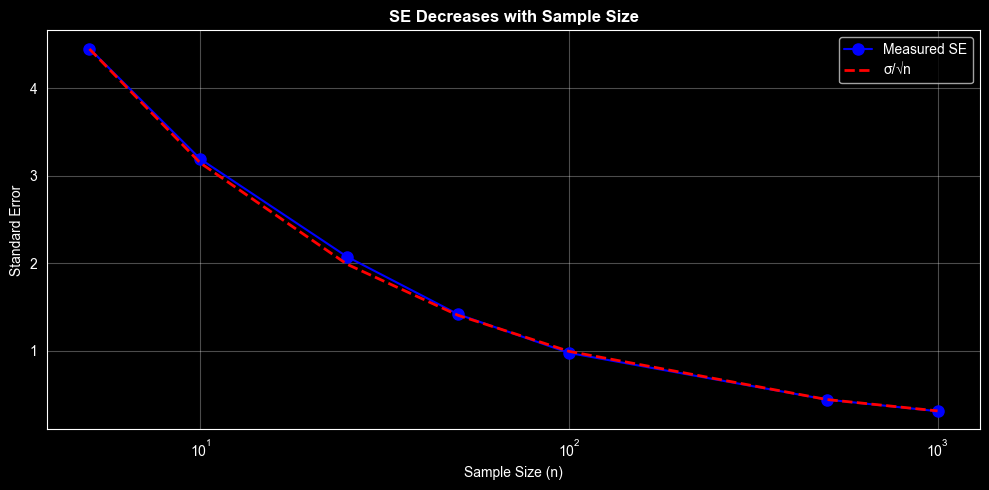

In [8]:
pop_std = np.std(population)
sizes = [5, 10, 25, 50, 100, 500, 1000]
measured, predicted = [], []

for n in sizes:
    means = [np.mean(np.random.choice(population, size=n)) for _ in range(1000)]
    measured.append(np.std(means))
    predicted.append(pop_std / np.sqrt(n))

print(f"{'n':>6}  {'Measured SE':>12}  {'Predicted':>10}")
for n, m, p in zip(sizes, measured, predicted):
    print(f"{n:>6}  {m:>12.3f}  {p:>10.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sizes, measured, 'bo-', label='Measured SE', ms=8)
ax.plot(sizes, predicted, 'r--', lw=2, label='σ/√n')
ax.set_xlabel('Sample Size (n)')
ax.set_ylabel('Standard Error')
ax.set_title('SE Decreases with Sample Size', fontweight='bold')
ax.legend()
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
stats.norm.ppf(0.025)

np.float64(-1.9599639845400545)

In [38]:
stats.norm.ppf(0.975)

np.float64(1.959963984540054)

In [39]:
stats.norm.ppf(0.16)

np.float64(-0.994457883209753)

In [40]:
stats.norm.ppf(0.84)

np.float64(0.994457883209753)

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 3: Confidence Intervals</h2>
</div>

$$95\% \text{ CI} = \bar{x} \pm 1.96 \times SE$$

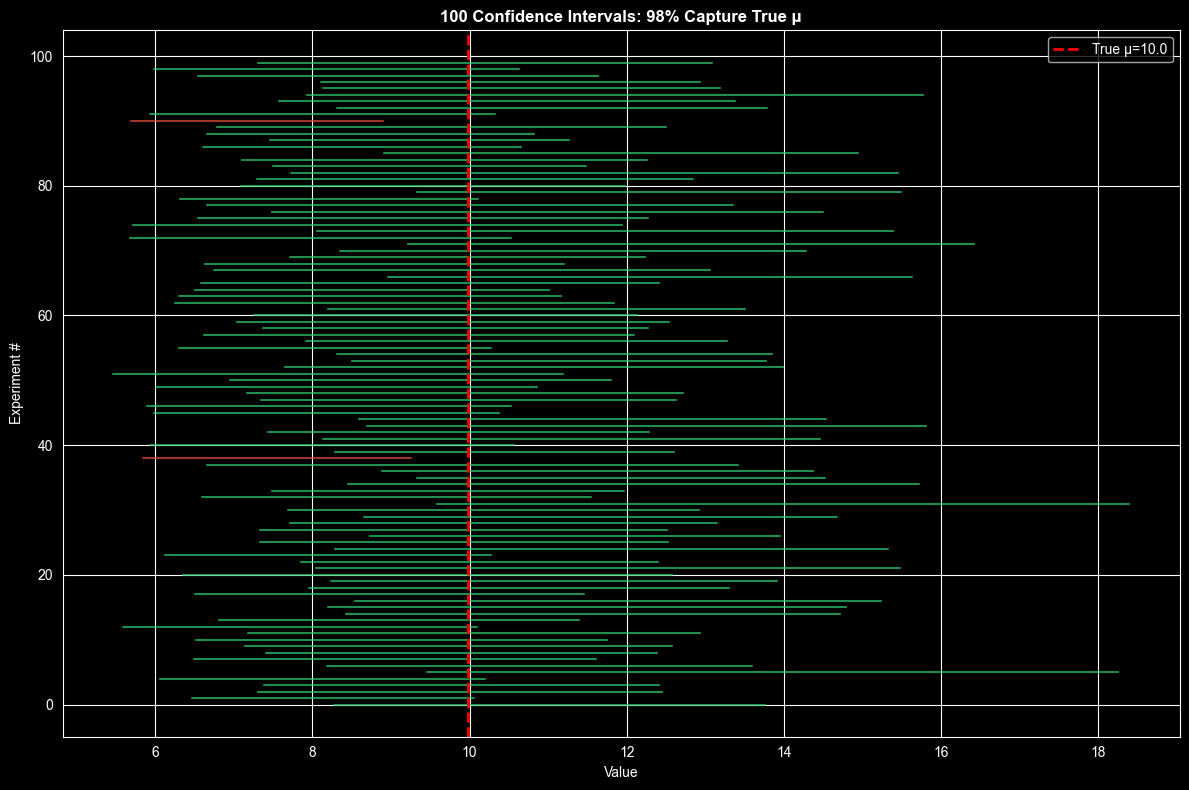

98/100 intervals captured the true mean (expected ~95)
9.982076333945145


In [10]:
# Simulate 100 confidence intervals
true_mu = np.mean(population)
n = 50
captured = 0

fig, ax = plt.subplots(figsize=(12, 8))
for i in range(100):
    s = np.random.choice(population, size=n)
    m = np.mean(s)
    se = np.std(s, ddof=1) / np.sqrt(n)
    lo, hi = m - 1.96*se, m + 1.96*se
    hit = lo <= true_mu <= hi
    captured += hit
    ax.plot([lo, hi], [i, i], color='#2ECC71' if hit else '#E74C3C', lw=1.5, alpha=0.7)

ax.axvline(true_mu, color='red', lw=2, ls='--', label=f'True μ={true_mu:.1f}')
ax.set_xlabel('Value')
ax.set_ylabel('Experiment #')
ax.set_title(f'100 Confidence Intervals: {captured}% Capture True μ', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(f"{captured}/100 intervals captured the true mean (expected ~95)")

print(true_mu)

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 4: Hypothesis Testing & A/B Test</h2>
</div>

<div style="background: #FEF9E7; color: black; border-left: 5px solid #F39C12; padding: 15px; margin: 15px 0;">
<strong>⚠️ Critical:</strong> The p-value is NOT "the probability H₀ is true." It is the probability of observing data this extreme IF H₀ were true. P(data|H₀) ≠ P(H₀|data).
</div>

In [14]:
# Simulate A/B test: website conversion rates
n_control = 1000
n_treatment = 1000
p_control_true = 0.052    # 5.2% true rate
p_treatment_true = 0.062  # 6.2% true rate (1pp uplift)

control = np.random.binomial(1, p_control_true, n_control)
treatment = np.random.binomial(1, p_treatment_true, n_treatment)

cr_c = np.mean(control)
cr_t = np.mean(treatment)
diff = cr_t - cr_c

print("=== A/B TEST DATA ===")
print(f"Control:   {np.sum(control)}/{n_control} = {cr_c*100:.1f}%")
print(f"Treatment: {np.sum(treatment)}/{n_treatment} = {cr_t*100:.1f}%")
print(f"Difference: {diff*100:.1f} percentage points")
print()

# Hypotheses
print("H₀: Treatment has no effect (conversion rates are equal)")
print("H₁: Treatment has an effect (conversion rates differ)")
print("α = 0.05")

=== A/B TEST DATA ===
Control:   51/1000 = 5.1%
Treatment: 50/1000 = 5.0%
Difference: -0.1 percentage points

H₀: Treatment has no effect (conversion rates are equal)
H₁: Treatment has an effect (conversion rates differ)
α = 0.05


In [15]:
# Run t-test
t_stat, p_value = stats.ttest_ind(treatment, control)

print(f"\n=== T-TEST RESULTS ===")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print()

# Confidence interval for difference
se_diff = np.sqrt(np.var(control, ddof=1)/n_control + np.var(treatment, ddof=1)/n_treatment)
ci_lo = diff - 1.96 * se_diff
ci_hi = diff + 1.96 * se_diff
print(f"95% CI for difference: [{ci_lo*100:.1f}pp, {ci_hi*100:.1f}pp]")
print()

# Decision
if p_value < 0.05:
    print(f"p={p_value:.4f} < 0.05 → REJECT H₀")
    print("The difference IS statistically significant.")
else:
    print(f"p={p_value:.4f} ≥ 0.05 → FAIL TO REJECT H₀")
    print("Insufficient evidence — difference may be noise.")

# Practical significance
print(f"\nPractical impact: {abs(diff)*100:.1f}pp lift")
print(f"If 100K visitors/month × ₹500 avg order:")
print(f"  Monthly revenue impact: ₹{abs(diff)*100000*500:,.0f}")


=== T-TEST RESULTS ===
t-statistic: -0.1021
p-value: 0.9187

95% CI for difference: [-2.0pp, 1.8pp]

p=0.9187 ≥ 0.05 → FAIL TO REJECT H₀
Insufficient evidence — difference may be noise.

Practical impact: 0.1pp lift
If 100K visitors/month × ₹500 avg order:
  Monthly revenue impact: ₹50,000


<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 5: Type I & Type II Errors</h2>
</div>

In [16]:
# Simulate Type I errors: test when there IS NO real effect
n_simulations = 1000
false_positives = 0

for _ in range(n_simulations):
    # Both groups have the SAME true rate (H₀ is true)
    a = np.random.binomial(1, 0.05, 500)
    b = np.random.binomial(1, 0.05, 500)
    _, p = stats.ttest_ind(a, b)
    if p < 0.05:
        false_positives += 1

print("=== TYPE I ERROR SIMULATION ===")
print(f"Simulations where H₀ is TRUE: {n_simulations}")
print(f"False positives (rejected true H₀): {false_positives}")
print(f"Type I error rate: {false_positives/n_simulations:.3f} (expected ≈ 0.050)")
print()
print("This confirms: with α=0.05, about 5% of tests")
print("give false positives even when there is NO real effect.")

=== TYPE I ERROR SIMULATION ===
Simulations where H₀ is TRUE: 1000
False positives (rejected true H₀): 56
Type I error rate: 0.056 (expected ≈ 0.050)

This confirms: with α=0.05, about 5% of tests
give false positives even when there is NO real effect.


<div style="background: #EAFAF1; border-left: 5px solid #2ECC71; padding: 15px; margin: 15px 0;">
<strong>✅ Key Takeaways:</strong>
<ol>
<li><strong>CLT:</strong> Sample means → Normal (n ≥ 30), regardless of population</li>
<li><strong>SE = σ/√n:</strong> Larger samples → more precision</li>
<li><strong>95% CI = x̄ ± 1.96 × SE</strong></li>
<li><strong>P-value ≠ P(H₀ is true)</strong> — the #1 misconception</li>
<li><strong>p < 0.05 → reject H₀</strong> (statistically significant)</li>
<li><strong>Type I (α):</strong> false positive. <strong>Type II (β):</strong> false negative</li>
<li><strong>Statistical significance ≠ practical importance</strong></li>
</ol>
</div>

## What's Next

**Session 7.3: Derivatives & Gradient Descent** — How ML models LEARN. Derivatives measure rate of change. Gradient descent minimizes error iteratively.

---
<div style="text-align:center; color:#666; padding:20px;"><em>Vishlesan i-Hub IIT Patna × Masai School</em></div>